In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/adhee/INFOSYS/Milestones/Milestone1/data/Clean-Data")
df

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,28,0,28.0
1,2023-01-01 01:00:00,119,0,84,0,203.0
2,2023-01-01 02:00:00,135,0,47,0,182.0
3,2023-01-01 03:00:00,171,0,21,0,192.0
4,2023-01-01 04:00:00,0,0,88,0,88.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,146,2221,23,0,2390.0
4317,2023-06-29 21:00:00,72,1887,31,0,1990.0
4318,2023-06-29 22:00:00,156,1982,0,0,2138.0
4319,2023-06-29 23:00:00,149,1143,43,0,1335.0


In [3]:
target_col = df['total_power']

In [4]:
df['time'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month


In [5]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


In [6]:
# Month cyclic encoding (12 months)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [7]:
df.head()

,timestamp,fridge,ac,lights,microwave,total_power,time,hour,month,hour_sin,hour_cos,month_sin,month_cos
0,2023-01-01 00:00:00,0,0,28,0,28.0,2023-01-01 00:00:00,0,1,0.000000,1.000000,0.5,0.866025
1,2023-01-01 01:00:00,119,0,84,0,203.0,2023-01-01 01:00:00,1,1,0.258819,0.965926,0.5,0.866025
2,2023-01-01 02:00:00,135,0,47,0,182.0,2023-01-01 02:00:00,2,1,0.500000,0.866025,0.5,0.866025
3,2023-01-01 03:00:00,171,0,21,0,192.0,2023-01-01 03:00:00,3,1,0.707107,0.707107,0.5,0.866025
4,2023-01-01 04:00:00,0,0,88,0,88.0,2023-01-01 04:00:00,4,1,0.866025,0.500000,0.5,0.866025


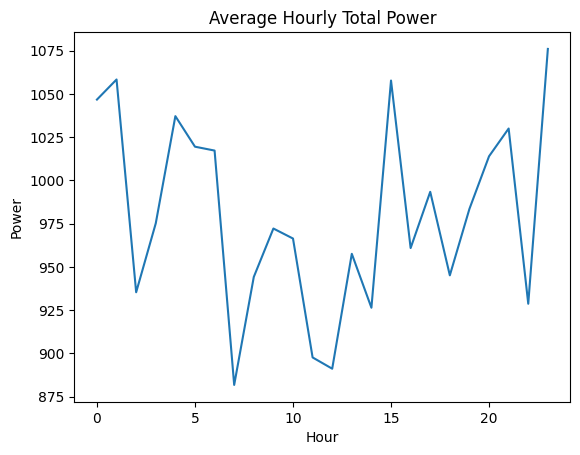

In [8]:
hourly_pattern = df.groupby('hour')['total_power'].mean()
import matplotlib.pyplot as plt
hourly_pattern.plot()
plt.title("Average Hourly Total Power")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

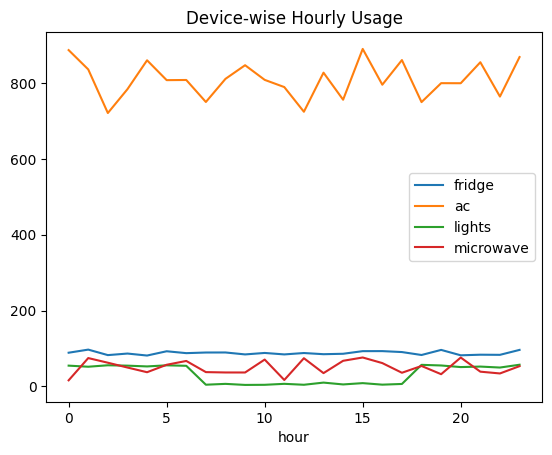

In [9]:
device_hourly = df.groupby('hour')[['fridge','ac','lights','microwave']].mean()
device_hourly.plot()
plt.title("Device-wise Hourly Usage")
plt.show()

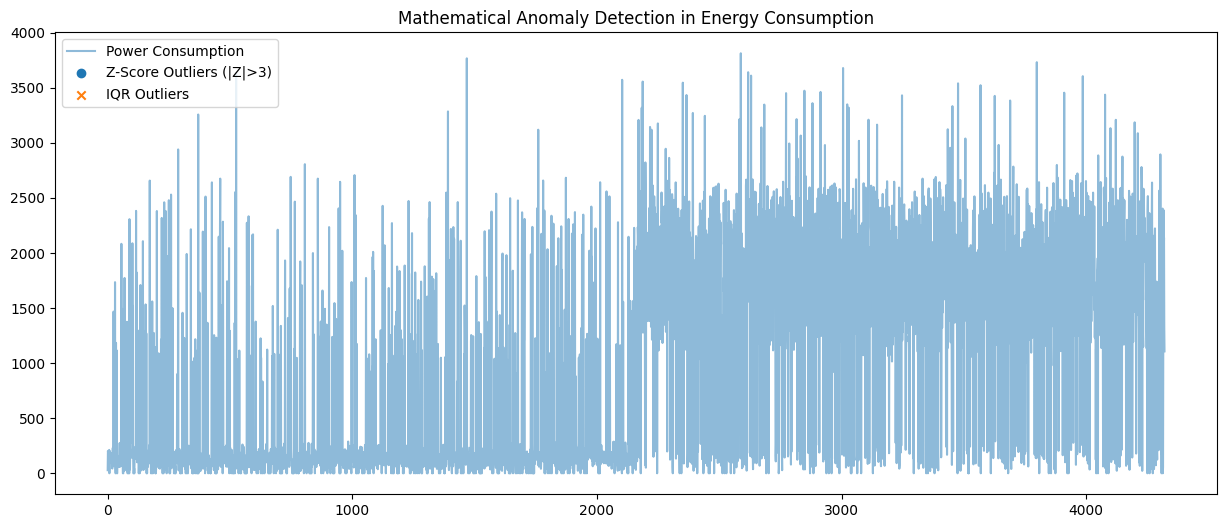

Number of Z-score outliers: 0
Number of IQR outliers: 0


In [13]:
# Select column properly
target_col = 'total_power'
# 1. Z-Score Method
from scipy import stats
import numpy as np
df['z_score'] = np.abs(stats.zscore(df[target_col]))
z_outliers = df[df['z_score'] > 3]
# 2. IQR Method
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

iqr_outliers = df[
    (df[target_col] < (Q1 - 1.5 * IQR)) |
    (df[target_col] > (Q3 + 1.5 * IQR))
]
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(df.index, df[target_col], label='Power Consumption', alpha=0.5)
plt.scatter(z_outliers.index, z_outliers[target_col], label='Z-Score Outliers (|Z|>3)')
plt.scatter(iqr_outliers.index, iqr_outliers[target_col], marker='x', label='IQR Outliers')
plt.title('Mathematical Anomaly Detection in Energy Consumption')
plt.legend()
plt.show()
print(f"Number of Z-score outliers: {len(z_outliers)}")
print(f"Number of IQR outliers: {len(iqr_outliers)}")

Shannon Entropy of total_power: 3.5209 bits


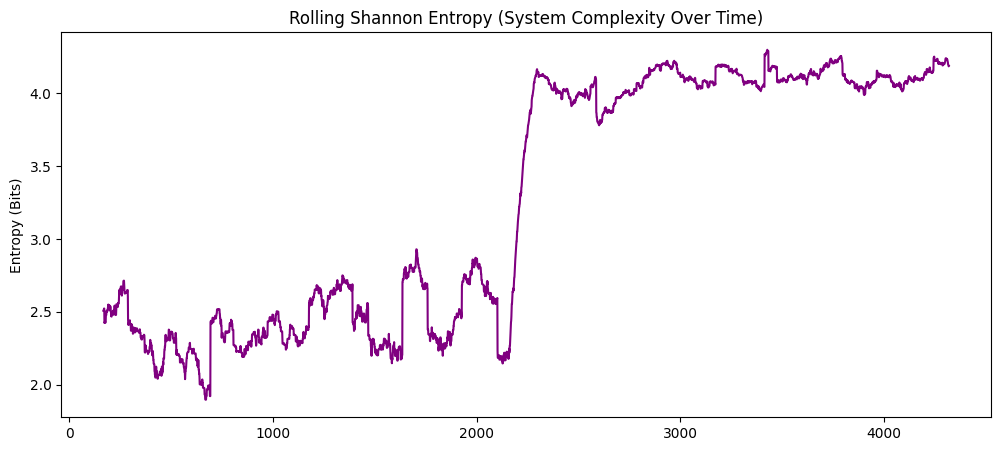

In [15]:
def calculate_entropy(series, bins=30):
    # Create a histogram of the data
    counts, _ = np.histogram(series, bins=bins, density=True)
    # Convert to probabilities
    probs = counts / np.sum(counts)
    # Remove zeros for log calculation
    probs = probs[probs > 0]
    # Calculate Shannon Entropy
    return -np.sum(probs * np.log2(probs))

entropy_val = calculate_entropy(df[target_col])
print(f"Shannon Entropy of {target_col}: {entropy_val:.4f} bits")

# Calculate entropy over a rolling window to see complexity changes over time
df['rolling_entropy'] = df[target_col].rolling(window=168).apply(calculate_entropy) # Weekly rolling

plt.figure(figsize=(12, 5))
df['rolling_entropy'].plot(color='purple')
plt.title('Rolling Shannon Entropy (System Complexity Over Time)')
plt.ylabel('Entropy (Bits)')
plt.show()

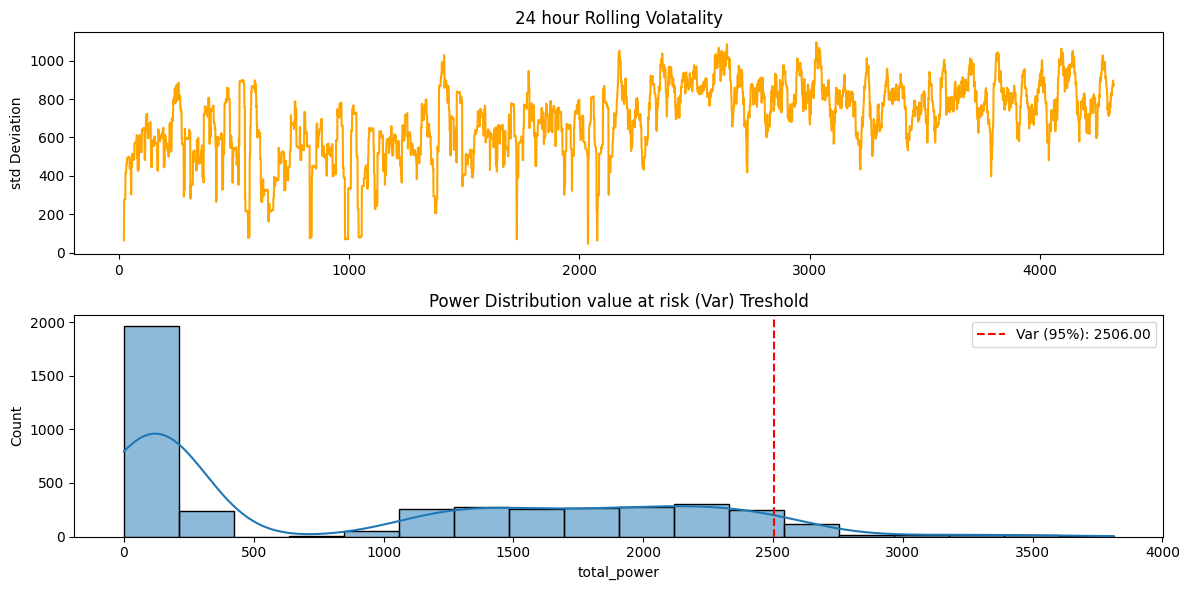

In [16]:
df['volatility'] = df[target_col].rolling(window=24).std()

var_95 = np.percentile(df[target_col],95)

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df['volatility'],color='orange')
plt.title('24 hour Rolling Volatality')
plt.ylabel('std Deviation')

plt.subplot(2,1,2)
sns.histplot(df[target_col],kde=True)
plt.axvline(var_95,color='red',linestyle='--',label=f'Var (95%): {var_95:.2f}')
plt.title('Power Distribution value at risk (Var) Treshold')
plt.legend()

plt.tight_layout()
plt.show()

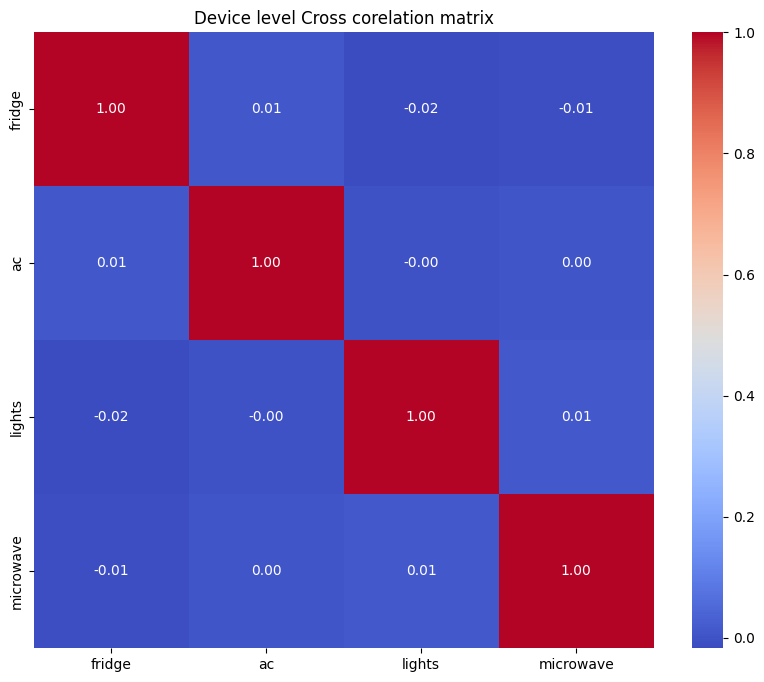

In [18]:
device_cols = ['fridge','ac','lights','microwave']
existing_device_cols = [ c for c in device_cols if c in df.columns]
if existing_device_cols:
    corr_matrix = df[existing_device_cols].corr()
# corr_matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
    plt.title("Device level Cross corelation matrix")
    plt.show()
else:
    print("Device columsn not found for the co-relation analysis")